# SATMM Santander: alerta temprana de movimientos en masa

Reto avanzado, Hackathon UDES. Documentación en `docs/`.

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')  # avisos de librerías (tqdm, shap) que no afectan resultados
sys.path.insert(0, 'src')

import pandas as pd
from satmm import datos, boletin

pd.set_option('display.max_columns', 30)

## 1. Carga y limpieza

Todos los cruces se hacen por `codigo_dane`, nunca por nombre.

In [2]:
panel = datos.cargar_panel()
emergencias = datos.cargar_emergencias()
municipios = datos.cargar_municipios()
panel.shape, emergencias.shape, municipios.shape

((11484, 10), (1472, 9), (87, 5))

In [3]:
datos.diagnostico(panel, emergencias, municipios)

,chequeo,valor
0,Nulos en panel,0
1,Nulos en emergencias,0
2,Eventos duplicados,0
3,Códigos del panel sin cabecera,0
4,Códigos de emergencias sin cabecera,0
5,Códigos con más de un nombre,0
6,Eventos con 0 personas afectadas,24
7,Meses en el panel,132
8,Municipios en el panel,87


**Problemas encontrados:** ver la tabla. Los datos llegan limpios (sin nulos, duplicados ni nombres inconsistentes). Hallazgos que sí afectan el modelo:

- `lluvia_mm` y `eventos_mes` son del mismo mes: **no se conocen el día 1** → se excluyen (fuga).
- `eventos_12m` de 2015 incluye historia de 2014 que no está en el panel → 2015 solo se usa para rezagos.
- Desbalance: ~8 % de meses con movimiento en masa.

In [4]:
emergencias['evento'].value_counts()

evento
Movimiento en masa    1009
Inundación             184
Incendio forestal      131
Vendaval                80
Creciente súbita        68
Name: count, dtype: int64

In [5]:
panel.groupby('mes')['hubo_mm'].mean().round(3).rename('tasa_hubo_mm').to_frame().T

mes,1,2,3,4,5,6,7,8,9,10,11,12
tasa_hubo_mm,0.014,0.021,0.076,0.156,0.139,0.06,0.043,0.049,0.067,0.176,0.148,0.044


## 2. Variables sin fuga

Cada fila del mes *t* usa solo información hasta *t − 1*. Las climatologías (`mm_hist_mes`, `lluvia_anom`) usan **solo años anteriores** al de la fila, así que no dependen del pliegue ni filtran el futuro. 2015 se usa solo para alimentar rezagos.

In [6]:
from satmm import variables

tabla = variables.construir(panel, emergencias, municipios)
print(tabla.shape, '| excluidas por fuga:', variables.EXCLUIDAS)
tabla[['codigo_dane', 'anio', 'mes'] + variables.FEATURES + ['hubo_mm']].head()

(10440, 23) | excluidas por fuga: ['lluvia_mm', 'eventos_mes', 'hubo_mm']


,codigo_dane,anio,mes,lluvia_t1,lluvia_t2,lluvia_2m,lluvia_anom,mm_12m,mm_hist_mes,eventos_12m,altitud_m,latitud,longitud,mes_sin,mes_cos,mes_sin2,mes_cos2,hubo_mm
0,68001,2016,1,29.7,65.2,94.9,0.482927,1.0,0.0,2,959,7.0693,-73.1355,0.500000,8.660254e-01,8.660254e-01,0.5,0
1,68001,2016,2,46.1,29.7,75.8,3.974138,1.0,0.0,2,959,7.0693,-73.1355,0.866025,5.000000e-01,8.660254e-01,-0.5,0
2,68001,2016,3,85.0,46.1,131.1,1.096774,1.0,0.0,1,959,7.0693,-73.1355,1.000000,6.123234e-17,1.224647e-16,-1.0,0
3,68001,2016,4,94.0,85.0,179.0,2.397959,1.0,0.0,1,959,7.0693,-73.1355,0.866025,-5.000000e-01,-8.660254e-01,-0.5,0
4,68001,2016,5,119.4,94.0,213.4,1.532734,1.0,0.0,1,959,7.0693,-73.1355,0.500000,-8.660254e-01,-8.660254e-01,0.5,0


In [7]:
# Evidencia de la fuga: la lluvia del mismo mes 'parece' el doble de útil que la del mes anterior
tabla[['lluvia_mm', 'lluvia_t1', 'lluvia_2m', 'mm_12m', 'mm_hist_mes', 'mes_sin2', 'hubo_mm']].corr()['hubo_mm'].round(3)

lluvia_mm      0.264
lluvia_t1      0.138
lluvia_2m      0.089
mm_12m         0.092
mm_hist_mes    0.116
mes_sin2      -0.190
hubo_mm        1.000
Name: hubo_mm, dtype: float64

## 3. Validación temporal y líneas base

Ventana expansiva por años: entrena con 2016…(a−1) y valida con el año *a* completo, para a = 2021…2024. **2025 no se toca** hasta la prueba final.

- **A:** repetir el mismo mes del año anterior.
- **B:** climatología del municipio en ese mes (solo años previos).

In [8]:
from satmm import validacion as va

[(p.anio_valida, f'{p.anios_train[0]}–{p.anios_train[-1]}') for p in va.pliegues()]

[(2021, '2016–2020'),
 (2022, '2016–2021'),
 (2023, '2016–2022'),
 (2024, '2016–2023')]

In [9]:
modelos = {
    'A: mismo mes año anterior': (None, va.linea_base_anio_anterior, 0.5),
    'B: climatología': (None, va.linea_base_climatologia, 0.1),
    'Logística': (va.logistica, None, 0.5),
}
res = va.evaluar(tabla, modelos)
va.resumen(res)

pr_auc               recall               precision  \
                            mean    min    max   mean    min    max      mean   
modelo                                                                          
Logística                  0.190  0.140  0.269  0.706  0.633  0.842     0.154   
B: climatología            0.143  0.093  0.213  0.619  0.480  0.722     0.139   
A: mismo mes año anterior  0.105  0.063  0.162  0.181  0.147  0.253     0.159   

                                         brier               top10_precision  \
                             min    max   mean    min    max            mean   
modelo                                                                         
Logística                  0.107  0.220  0.229  0.194  0.271           0.158   
B: climatología            0.081  0.211  0.088  0.057  0.127           0.138   
A: mismo mes año anterior  0.114  0.245  0.164  0.112  0.195           0.112   

                                        alertas_mes                  
                             min    max        mean     min     max  
modelo                                                               
Logística                  0.050  0.283      36.625  28.083  48.417  
B: climatología            0.067  0.225      35.646  29.083  40.917  
A: mismo mes año anterior  0.067  0.167       9.062   6.583  12.667

In [10]:
res.pivot(index='anio', columns='modelo', values='pr_auc').round(3)

modelo,A: mismo mes año anterior,B: climatología,Logística
anio,,,
2021,0.105,0.135,0.210
2022,0.162,0.213,0.269
2023,0.090,0.129,0.140
2024,0.063,0.093,0.140


### Evidencia de la fuga
Misma logística, pero agregando `lluvia_mm` (lluvia del mismo mes, desconocida el día 1). La mejora es **falsa**: en producción ese dato no existe.

In [11]:
feats_fuga = variables.FEATURES + ['lluvia_mm']
fuga = va.evaluar(tabla, {'Logística + lluvia_mm (FUGA)': (va.logistica, None, 0.5)}, features=feats_fuga)
pd.concat([res[res.modelo == 'Logística'], fuga]).groupby('modelo')[['pr_auc', 'recall', 'precision']].mean().round(3)

,pr_auc,recall,precision
modelo,,,
Logística,0.190,0.706,0.154
Logística + lluvia_mm (FUGA),0.256,0.660,0.180


## 4. Modelo, umbral y semáforo

### Selección de modelo
XGBoost **sin peso de clase**: mejor PR-AUC y probabilidades calibradas (Brier ≈ climatología o mejor), porque el boletín publica la probabilidad. El desbalance se maneja con el umbral, no con pesos.

In [12]:
from satmm import modelo as mo

comparacion = va.evaluar(tabla, {
    'A: mismo mes año anterior': (None, va.linea_base_anio_anterior, 0.5),
    'B: climatología': (None, va.linea_base_climatologia, 0.1),
    'Logística': (va.logistica, None, 0.5),
    'XGBoost': (mo.xgboost, None, 0.1),
})
comparacion.pivot(index='anio', columns='modelo', values='pr_auc').round(3)

modelo,A: mismo mes año anterior,B: climatología,Logística,XGBoost
anio,,,,
2021,0.105,0.135,0.210,0.192
2022,0.162,0.213,0.269,0.306
2023,0.090,0.129,0.140,0.210
2024,0.063,0.093,0.140,0.155


In [13]:
comparacion.groupby('modelo')[['pr_auc', 'brier', 'top10_precision']].mean().round(3).sort_values('pr_auc', ascending=False)

,pr_auc,brier,top10_precision
modelo,,,
XGBoost,0.216,0.079,0.162
Logística,0.190,0.229,0.158
B: climatología,0.143,0.088,0.138
A: mismo mes año anterior,0.105,0.164,0.112


### Umbral (elegido en 2024 y congelado)
- **Amarillo:** probabilidad ≥ umbral que detecta el 70 % de los meses con movimiento en masa en 2024 → vigilancia.
- **Rojo:** los **10 municipios más altos de cada mes** que además superan el amarillo → capacidad del consejo para movilizar recursos.

In [14]:
F = variables.FEATURES
tr24, va24 = va.separar(tabla, va.pliegues()[-1])
p24 = mo.xgboost().fit(tr24[F], tr24['hubo_mm']).predict_proba(va24[F])[:, 1]
umbrales = mo.elegir_umbrales(va24, p24, recall_amarillo=0.70, rojos_mes=10)
umbrales

Umbrales(amarillo=0.05960889533162117, rojos_mes=10)

### Prueba final: 2025 (se evalúa una sola vez)

In [15]:
final = tabla[tabla['anio'] <= 2024]
prueba = tabla[tabla['anio'] == 2025].copy()
modelo_final = mo.xgboost().fit(final[F], final['hubo_mm'])
prueba['p'] = modelo_final.predict_proba(prueba[F])[:, 1]
prueba['nivel'] = mo.semaforo(prueba, prueba['p'].to_numpy(), umbrales)

pd.DataFrame({
    'XGBoost': va.metricas(prueba, prueba['p'].to_numpy(), umbrales.amarillo),
    'A: mismo mes año anterior': va.metricas(prueba, va.linea_base_anio_anterior(prueba), 0.5),
    'B: climatología': va.metricas(prueba, va.linea_base_climatologia(prueba), 0.1),
}).round(3)

,XGBoost,A: mismo mes año anterior,B: climatología
pr_auc,0.204,0.106,0.144
recall,0.838,0.111,0.717
precision,0.156,0.196,0.140
brier,0.082,0.127,0.088
top10_precision,0.158,0.150,0.150
alertas_mes,44.250,4.667,42.250
tasa_real,0.095,0.095,0.095


In [16]:
pd.Series(mo.evaluar_semaforo(prueba, prueba['p'].to_numpy(), umbrales)).round(3)

recall_rojo_o_amarillo     0.838
recall_rojo                0.192
precision_rojo             0.194
precision_amarillo         0.148
rojos_por_mes              8.167
amarillos_por_mes         36.083
eventos_por_mes            8.250
dtype: float64

In [17]:
# Semáforo mes a mes en 2025 frente a lo que pasó
prueba.groupby('mes').apply(lambda g: pd.Series({
    'rojos': (g.nivel == 'Rojo').sum(), 'amarillos': (g.nivel == 'Amarillo').sum(),
    'eventos_reales': g.hubo_mm.sum(), 'detectados': g[g.nivel != 'Verde'].hubo_mm.sum()})).T

mes,1,2,3,4,5,6,7,8,9,10,11,12
rojos,0,0,10,10,10,10,8,10,10,10,10,10
amarillos,0,0,19,71,77,16,0,25,56,77,68,24
eventos_reales,1,1,6,23,7,1,5,9,4,12,24,6
detectados,0,0,3,23,7,1,2,5,4,12,22,4


### Falsos negativos
Municipios con movimiento en masa en 2025 que el semáforo dejó en verde. Patrones: la mayoría ocurre en **meses secos**, cuando el sistema casi no alerta, y la mitad **no tenía movimientos en masa en los 12 meses previos**. El modelo depende de la temporada y del historial; un municipio que no reporta es casi invisible (subregistro).

In [18]:
fn = prueba[(prueba.hubo_mm == 1) & (prueba.nivel == 'Verde')]
print(f'{len(fn)} de {int(prueba.hubo_mm.sum())} meses con evento quedaron en verde')
fn[['municipio', 'mes', 'p', 'lluvia_2m', 'mm_12m', 'mm_hist_mes']].sort_values('p')

16 de 99 meses con evento quedaron en verde


,municipio,mes,p,lluvia_2m,mm_12m,mm_hist_mes
5148,Jesús María,1,0.013112,242.5,0.0,0.0
5749,Lebrija,2,0.015935,101.1,0.0,0.0
7074,Palmas del Socorro,7,0.021222,174.4,0.0,0.0
3234,El Guacamayo,7,0.023016,202.4,0.0,0.0
7439,Pinchote,12,0.025694,405.6,0.0,0.0
1910,Charalá,3,0.033169,119.3,0.0,0.0
1194,Cabrera,7,0.035357,351.8,0.0,0.0
4315,Girón,8,0.040302,257.3,2.0,0.0
3235,El Guacamayo,8,0.044378,142.1,1.0,0.0
5278,Jordán,11,0.045815,247.1,0.0,0.0


### Alertas del mes para el mapa y el boletín

In [19]:
from satmm import explicacion as ex

ANIO, MES = 2025, 4  # abril: temporada de lluvias
alertas = mo.alertas_mes(modelo_final, tabla, ANIO, MES, umbrales, municipios)
alertas = ex.agregar_razones(alertas, modelo_final, F)
alertas['nivel'].value_counts()

nivel
Amarillo    71
Rojo        10
Verde        6
Name: count, dtype: int64

In [20]:
alertas[['ranking', 'municipio', 'nivel', 'p', 'lluvia_2m', 'mm_12m', 'hubo_mm']].head(12)

,ranking,municipio,nivel,p,lluvia_2m,mm_12m,hubo_mm
0,1,San Andrés,Rojo,0.375715,529.6,2.0,1
1,2,Suratá,Rojo,0.313691,312.7,2.0,0
2,3,Carcasí,Rojo,0.311930,346.9,2.0,0
3,4,Guaca,Rojo,0.301308,343.8,0.0,0
4,5,Encino,Rojo,0.292647,340.6,1.0,0
5,6,Tona,Rojo,0.286000,219.1,3.0,0
6,7,Bolívar,Rojo,0.276833,293.1,0.0,0
7,8,La Paz,Rojo,0.271634,287.0,1.0,1
8,9,Guavatá,Rojo,0.266057,341.2,0.0,0
9,10,Concepción,Rojo,0.261450,343.4,0.0,0


## 5. Explicación (SHAP)

SHAP reparte cada predicción entre las variables. Las 14 variables técnicas se agrupan en **7 factores** que entiende un consejo municipal (lluvia reciente, temporada, relieve, historial…).

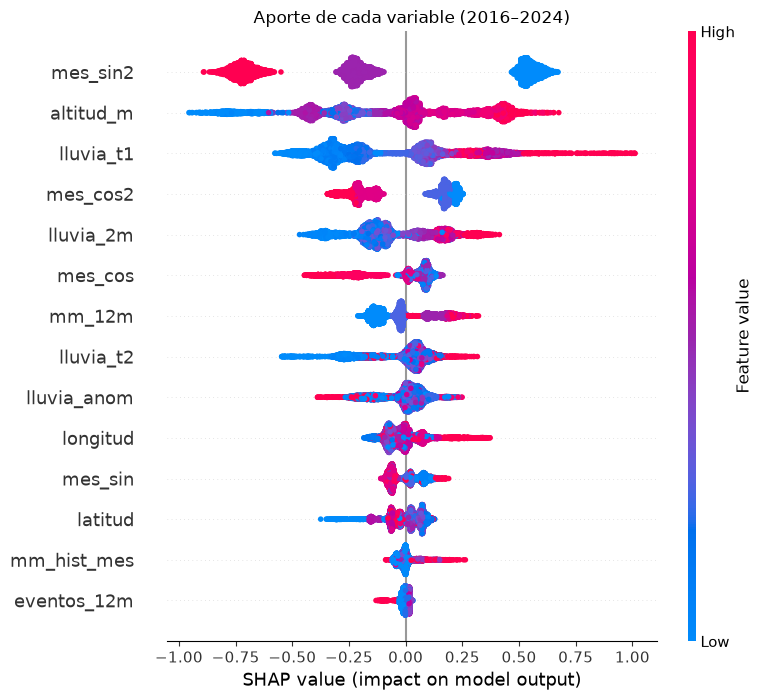

In [21]:
import shap, matplotlib.pyplot as plt

sv = ex.valores_shap(modelo_final, final[F])
shap.summary_plot(sv.to_numpy(), final[F], show=False, max_display=14)
plt.title('Aporte de cada variable (2016–2024)'); plt.tight_layout(); plt.savefig('out/shap_global.png', dpi=120); plt.show(); plt.close('all')

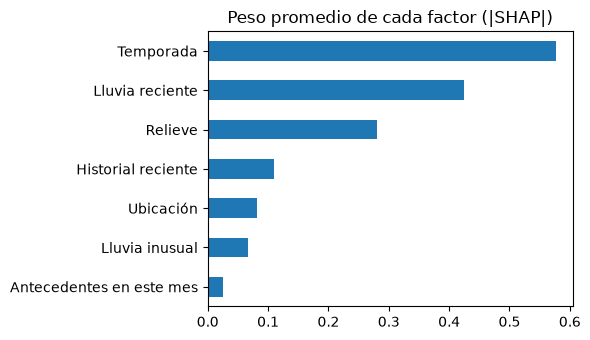

In [22]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ex.por_factor(sv).abs().mean().sort_values().plot.barh(ax=ax, title='Peso promedio de cada factor (|SHAP|)')
fig.tight_layout(); fig.savefig('out/shap_factores.png', dpi=120); plt.show()

### Chequeo de sentido común
El riesgo debe **subir** con la lluvia, el historial y la altitud. Correlación de Spearman entre el valor de la variable y su aporte SHAP (positivo = sube el riesgo):

In [23]:
pd.Series({c: ex.chequeo_monotonia(modelo_final, final[F], c) for c in ['lluvia_t1', 'lluvia_2m', 'mm_12m', 'altitud_m', 'mm_hist_mes']}).round(3)

lluvia_t1      0.941
lluvia_2m      0.812
mm_12m         0.942
altitud_m      0.913
mm_hist_mes    0.330
dtype: float64

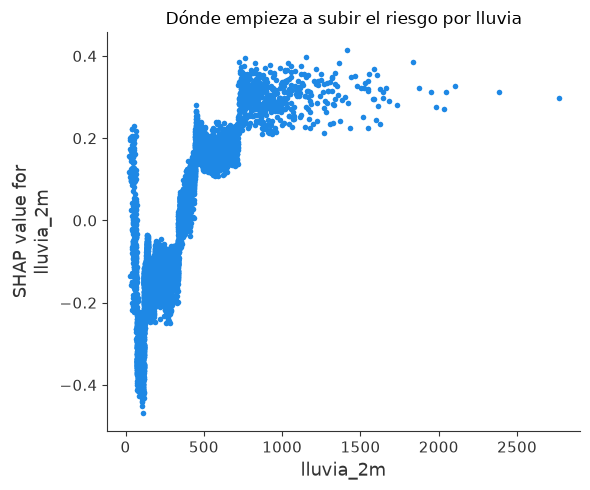

In [24]:
shap.dependence_plot('lluvia_2m', sv.to_numpy(), final[F], interaction_index=None, show=False)
plt.title('Dónde empieza a subir el riesgo por lluvia'); plt.tight_layout(); plt.show(); plt.close('all')

### Explicación por municipio
Para cada municipio se toman los 3 factores **propios** que más suben su probabilidad (la temporada se reporta aparte porque es igual para todos los municipios del mes).

In [25]:
for _, a in alertas[alertas.nivel == 'Rojo'].head(5).iterrows():
    print(f"{a.ranking:>2}. {a.municipio} ({a.nivel}, {100*a.p:.1f} %)")
    for r in a.razones:
        print('     •', ex.texto_razon(r, MES, boletin.num))

 1. San Andrés (Rojo, 37.6 %)
     • lluvia de los dos meses anteriores: 529,6 mm (mes anterior: 460,3 mm)
     • cabecera a 1.650 m de altitud
     • 2 movimientos en masa y 2 emergencias en total en los últimos 12 meses
 2. Suratá (Rojo, 31.4 %)
     • cabecera a 1.800 m de altitud
     • 2 movimientos en masa y 2 emergencias en total en los últimos 12 meses
     • lluvia de los dos meses anteriores: 312,7 mm (mes anterior: 264,6 mm)
 3. Carcasí (Rojo, 31.2 %)
     • cabecera a 1.710 m de altitud
     • ubicación dentro del departamento
     • 2 movimientos en masa y 2 emergencias en total en los últimos 12 meses
 4. Guaca (Rojo, 30.1 %)
     • lluvia de los dos meses anteriores: 343,8 mm (mes anterior: 266,9 mm)
     • cabecera a 2.400 m de altitud
     • la lluvia del mes anterior fue 1,4 veces su promedio para esa época
 5. Encino (Rojo, 29.3 %)
     • lluvia de los dos meses anteriores: 340,6 mm (mes anterior: 259,4 mm)
     • ubicación dentro del departamento
     • en años ante

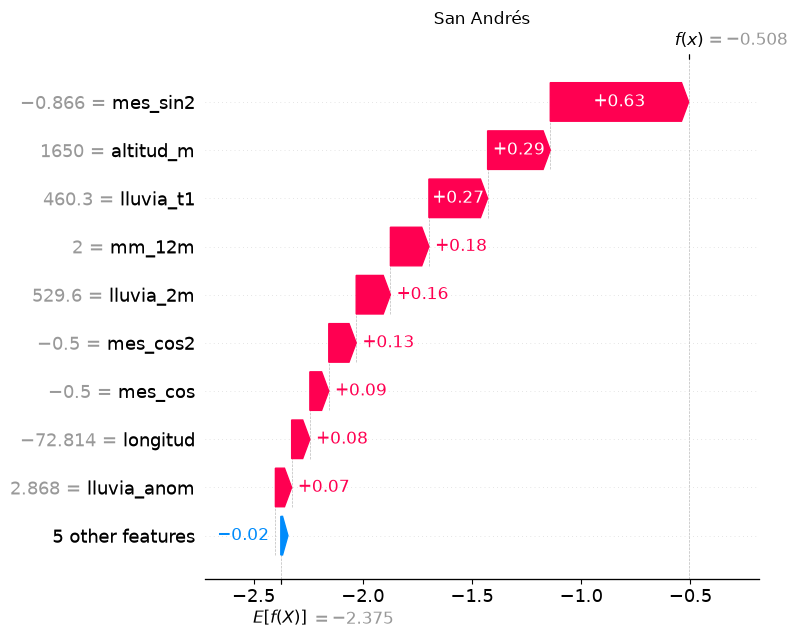

In [26]:
# Cascada del municipio #1: de la tasa base a su probabilidad
i = alertas.index[0]
exp = shap.TreeExplainer(modelo_final)(alertas[F])
shap.plots.waterfall(exp[i], max_display=10, show=False)
plt.title(alertas.loc[i, 'municipio']); plt.tight_layout(); plt.show()

## 6. Mapa de alertas

In [27]:
from satmm import mapa

m = mapa.construir(alertas, f'Alertas {MES:02d}/{ANIO} (provisional)')
m.save('out/mapa_alertas.html')
m

## 7. Boletín verificado

In [28]:
texto, _ = boletin.generar(alertas.iloc[0], emergencias, len(alertas))
open('out/boletin.md', 'w').write(texto)
from IPython.display import Markdown
Markdown(texto)

# Boletín de alerta temprana: movimientos en masa

**Municipio:** San Andrés · **Mes:** abril de 2025 · **Nivel:** Rojo

San Andrés quedó en el puesto 1 de 87 municipios de Santander por riesgo estimado de movimiento en masa para abril. Probabilidad estimada de al menos un movimiento en masa en el mes: 37,6 %.

## Por qué está en alerta
- Abril es temporada de lluvias en Santander: el riesgo sube en todo el departamento.
- Lluvia de los dos meses anteriores: 529,6 mm (mes anterior: 460,3 mm).
- Cabecera a 1.650 m de altitud.
- 2 movimientos en masa y 2 emergencias en total en los últimos 12 meses.

## Antecedentes (últimos 12 meses)
- Emergencias registradas: 2.
- Personas afectadas: 34.
- Viviendas afectadas: 5.

## Acciones sugeridas
- Convocar al consejo municipal de gestión del riesgo.
- Inspeccionar taludes, vías y viviendas con antecedentes de deslizamiento.
- Preparar rutas de evacuación y alojamientos temporales.

## Límites
Estimación mensual con lluvia medida en la cabecera municipal: no anticipa aguaceros de pocas horas, el lugar exacto ni eventos no reportados.


### Prueba del verificador
Se agrega una cifra inventada al boletín: el verificador debe señalarla.

In [29]:
c = boletin.cifras(alertas.iloc[0], emergencias, len(alertas))
boletin.verificar(texto + '\nSe estiman 350 viviendas en riesgo.', c)

[350.0]

## Tablero
Un mapa por mes de 2025, boletines verificados para **todos** los municipios en rojo, y el tablero `out/tablero.html` que lo junta (abrir en el navegador).

In [30]:
from satmm import tablero

m25 = va.metricas(prueba, prueba['p'].to_numpy(), umbrales.amarillo)
sem = mo.evaluar_semaforo(prueba, prueba['p'].to_numpy(), umbrales)
metricas_2025 = {
    'recall_alerta': sem['recall_rojo_o_amarillo'], 'precision_rojo': sem['precision_rojo'],
    'tasa_base': m25['tasa_real'], 'pr_auc': m25['pr_auc'],
    'pr_auc_A': va.metricas(prueba, va.linea_base_anio_anterior(prueba), 0.5)['pr_auc'],
    'pr_auc_B': va.metricas(prueba, va.linea_base_climatologia(prueba), 0.1)['pr_auc'],
    'recall_A': va.metricas(prueba, va.linea_base_anio_anterior(prueba), 0.5)['recall'],
    'fn': len(fn), 'eventos': int(prueba['hubo_mm'].sum()),
}
tablero.generar(modelo_final, tabla, umbrales, municipios, emergencias, metricas_2025)

{'boletines': 98, 'cifras_intrusas': 0}

## 8. Qué no puede anticipar el sistema

1. **Lo que no se reporta.** El modelo aprende del historial: un municipio que reporta poco parece seguro (subregistro). No distingue "no pasa" de "no se reporta".
2. **Aguaceros de pocas horas.** La lluvia es mensual y medida en la cabecera municipal: no ve picos diarios ni la lluvia en veredas altas, que son las que detonan deslizamientos.
3. **Dónde y cuándo exactamente.** Responde municipio y mes, no vereda ni día.
4. **Detonantes no climáticos:** sismos, cortes de talud por obras, deforestación, fugas de acueducto.
5. **Meses secos.** En 2025, 11 de los 16 deslizamientos no detectados ocurrieron fuera de temporada, cuando el sistema casi no alerta.
6. **Cambios en cómo se reporta** (una alcaldía que empieza a reportar más) se confunden con cambios en el riesgo.

**Con lluvia diaria** usaríamos máximos de 1, 3 y 7 días y lluvia antecedente con decaimiento (los indicadores físicos de los umbrales de deslizamiento), y la alerta podría ser semanal.

## Qué decidimos no construir
- **Tablero web con servidor** (Streamlit/Dash): el tablero HTML estático abre en cualquier navegador sin instalar nada.
- **Pronóstico de lluvia** para el mes en curso.
- **Modelo espacial** (riesgo de los municipios vecinos).
- **Ajuste fino de hiperparámetros:** con 87 municipios, el riesgo de sobreajustar a un año es mayor que la ganancia.

## Con dos horas más
1. Agregar el riesgo de los municipios vecinos.
2. Afinar el umbral por temporada: en meses secos se concentran los falsos negativos.
3. Construir con el consejo una curva de costo (falsa alarma frente a evento no anticipado) para fijar el umbral con su criterio.